# Notebook 01 — Exploratory Data Analysis

**Project:** Planetary Defence Officer — ESA NEOCC Simulator  
**Dataset:** NASA NEO Classification (NEOWS via Kaggle)  
**Purpose:** Understand dataset structure, class imbalance severity, feature distributions,
and redundancy. All findings drive preprocessing decisions in notebook 02.

Seed: `42` throughout.

---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os

os.makedirs('output', exist_ok=True)

PALETTE = {
    'bg': '#080808', 'surface': '#111111', 'border': '#363636',
    'muted': '#707070', 'text': '#c0c0c0', 'bright': '#dedede',
    'ok': '#6aac79', 'warn': '#c8a235', 'crit': '#c84040',
}

plt.rcParams.update({
    'figure.facecolor': PALETTE['bg'], 'axes.facecolor': PALETTE['bg'],
    'axes.edgecolor': PALETTE['border'], 'text.color': PALETTE['text'],
    'axes.labelcolor': PALETTE['text'], 'xtick.color': PALETTE['muted'],
    'ytick.color': PALETTE['muted'], 'grid.color': '#1a1a1a',
    'grid.alpha': 0.6, 'font.family': 'monospace',
    'axes.titlecolor': PALETTE['bright'], 'axes.titlesize': 12,
    'axes.labelsize': 10, 'legend.facecolor': '#080808',
    'legend.edgecolor': '#363636', 'legend.labelcolor': '#c0c0c0',
})

df = pd.read_csv('data/raw/nasa.csv')
print(f"Shape: {df.shape}")
print(f"Columns ({len(df.columns)}):")
for c in df.columns:
    print(f"  {c:<45} {df[c].dtype}")

Shape: (4687, 40)
Columns (40):
  Neo Reference ID                              int64
  Name                                          int64
  Absolute Magnitude                            float64
  Est Dia in KM(min)                            float64
  Est Dia in KM(max)                            float64
  Est Dia in M(min)                             float64
  Est Dia in M(max)                             float64
  Est Dia in Miles(min)                         float64
  Est Dia in Miles(max)                         float64
  Est Dia in Feet(min)                          float64
  Est Dia in Feet(max)                          float64
  Close Approach Date                           str
  Epoch Date Close Approach                     int64
  Relative Velocity km per sec                  float64
  Relative Velocity km per hr                   float64
  Miles per hour                                float64
  Miss Dist.(Astronomical)                      float64
  Miss Dist.(lunar)       

## 1. Class distribution

The target variable is `Hazardous` (boolean). We convert it to int later.
The imbalance ratio defines the core challenge: naive classifiers learn to always predict SAFE
and still achieve high accuracy — we will demonstrate this failure mode explicitly in notebook 03.

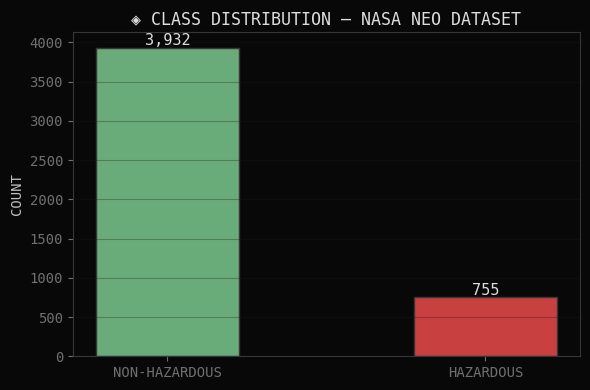

Non-hazardous : 3,932  (83.9%)
Hazardous     : 755   (16.1%)
Imbalance ratio: 5.2:1  (majority:minority)


In [4]:
counts = df['Hazardous'].value_counts()
ratio = counts[False] / counts[True]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ['NON-HAZARDOUS', 'HAZARDOUS'],
    [counts[False], counts[True]],
    color=[PALETTE['ok'], PALETTE['crit']],
    edgecolor=PALETTE['border'],
    width=0.45,
)
for bar, count in zip(bars, [counts[False], counts[True]]):
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 30,
            f'{count:,}', ha='center', color=PALETTE['bright'], fontsize=11)
ax.set_title('◈ CLASS DISTRIBUTION — NASA NEO DATASET')
ax.set_ylabel('COUNT')
ax.grid(axis='y', alpha=0.3)
for spine in ax.spines.values():
    spine.set_edgecolor(PALETTE['border'])
plt.tight_layout()
plt.savefig('output/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Non-hazardous : {counts[False]:,}  ({100 * counts[False] / len(df):.1f}%)")
print(f"Hazardous     : {counts[True]:,}   ({100 * counts[True] / len(df):.1f}%)")
print(f"Imbalance ratio: {ratio:.1f}:1  (majority:minority)")

## 2. Save Neo Reference IDs

The `Neo Reference ID` column is the asteroid's identifier in NASA's catalogue.
We save it before dropping so notebook 07 (export) can generate realistic game object IDs.

In [5]:
neo_ids = df['Neo Reference ID'].tolist()
with open('output/neo_ids.json', 'w') as f:
    json.dump(neo_ids, f)
print(f"Saved {len(neo_ids):,} Neo Reference IDs → output/neo_ids.json")

Saved 4,687 Neo Reference IDs → output/neo_ids.json


## 3. Column inventory and drop candidates

**Always drop** (non-informative or string-only):
- `Name` — human-readable label, no predictive value
- `Neo Reference ID` — identifier, saved above
- `Close Approach Date` — string date; the epoch numeric version is equally useless as a feature
- `Orbit Determination Date` — administrative timestamp
- `Equinox` — constant value "J2000" across all rows
- `Orbiting Body` — constant value "Earth" across all rows

**Unit-redundant** — same measurement in multiple units, keep km:
- Diameter: km / m / miles / feet → keep `Est Dia in KM(*)`
- Velocity: km/s / km/h / mph → keep `Relative Velocity km per sec`
- Miss distance: AU / lunar / km / miles → keep `Miss Dist.(Astronomical)`

**Derived orbital elements** — mathematically redundant with other features:
- `Orbital Period` — T = a^1.5 years (Kepler 3rd), ~perfect correlation with `Semi Major Axis`
- `Mean Motion` — n = 360/T, derived from period
- `Perihelion Time` — reference epoch, not a physical property of the asteroid
- `Epoch Osculation` — reference epoch
- `Epoch Date Close Approach` — timestamp of a specific event, not an asteroid property
- `Orbit ID` — administrative tracking number

**Orientation angles** — describe spatial orientation at a reference epoch, not hazard:
- `Asc Node Longitude` (Ω), `Perihelion Arg` (ω), `Mean Anomaly` (M)

We confirm the derived redundancies with the correlation matrix below.

In [6]:
ALWAYS_DROP = [
    'Name', 'Close Approach Date', 'Orbit Determination Date',
    'Equinox', 'Orbiting Body', 'Neo Reference ID',
]

UNIT_REDUNDANT = [
    'Est Dia in M(min)', 'Est Dia in M(max)',
    'Est Dia in Miles(min)', 'Est Dia in Miles(max)',
    'Est Dia in Feet(min)', 'Est Dia in Feet(max)',
    'Relative Velocity km per hr', 'Miles per hour',
    'Miss Dist.(lunar)', 'Miss Dist.(kilometers)', 'Miss Dist.(miles)',
]

DERIVED_OR_ADMIN = [
    'Orbital Period', 'Mean Motion', 'Perihelion Time',
    'Epoch Osculation', 'Epoch Date Close Approach', 'Orbit ID',
]

ORIENTATION_ANGLES = ['Asc Node Longitude', 'Perihelion Arg', 'Mean Anomaly']

ALL_DROP = ALWAYS_DROP + UNIT_REDUNDANT + DERIVED_OR_ADMIN + ORIENTATION_ANGLES
FEATURES_KEPT = [c for c in df.columns if c not in ALL_DROP and c != 'Hazardous']

print(f"Columns dropped: {len(ALL_DROP)}")
print(f"Features kept:   {len(FEATURES_KEPT)}")
print()
print("FEATURES RETAINED FOR MODELLING")
print("=" * 50)
for i, f in enumerate(FEATURES_KEPT, 1):
    print(f"  {i:2d}. {f}")

Columns dropped: 26
Features kept:   13

FEATURES RETAINED FOR MODELLING
   1. Absolute Magnitude
   2. Est Dia in KM(min)
   3. Est Dia in KM(max)
   4. Relative Velocity km per sec
   5. Miss Dist.(Astronomical)
   6. Orbit Uncertainity
   7. Minimum Orbit Intersection
   8. Jupiter Tisserand Invariant
   9. Eccentricity
  10. Semi Major Axis
  11. Inclination
  12. Perihelion Distance
  13. Aphelion Dist


## 4. Correlation matrix — confirming redundancy

The heatmap below confirms our drop decisions.
Expected near-perfect correlations (|r| ≈ 1):
- `Orbital Period` ↔ `Semi Major Axis` (Kepler 3rd law)
- `Mean Motion` ↔ `Orbital Period` (n = 360/T)
- All diameter-unit columns with each other
- All miss-distance-unit columns with each other

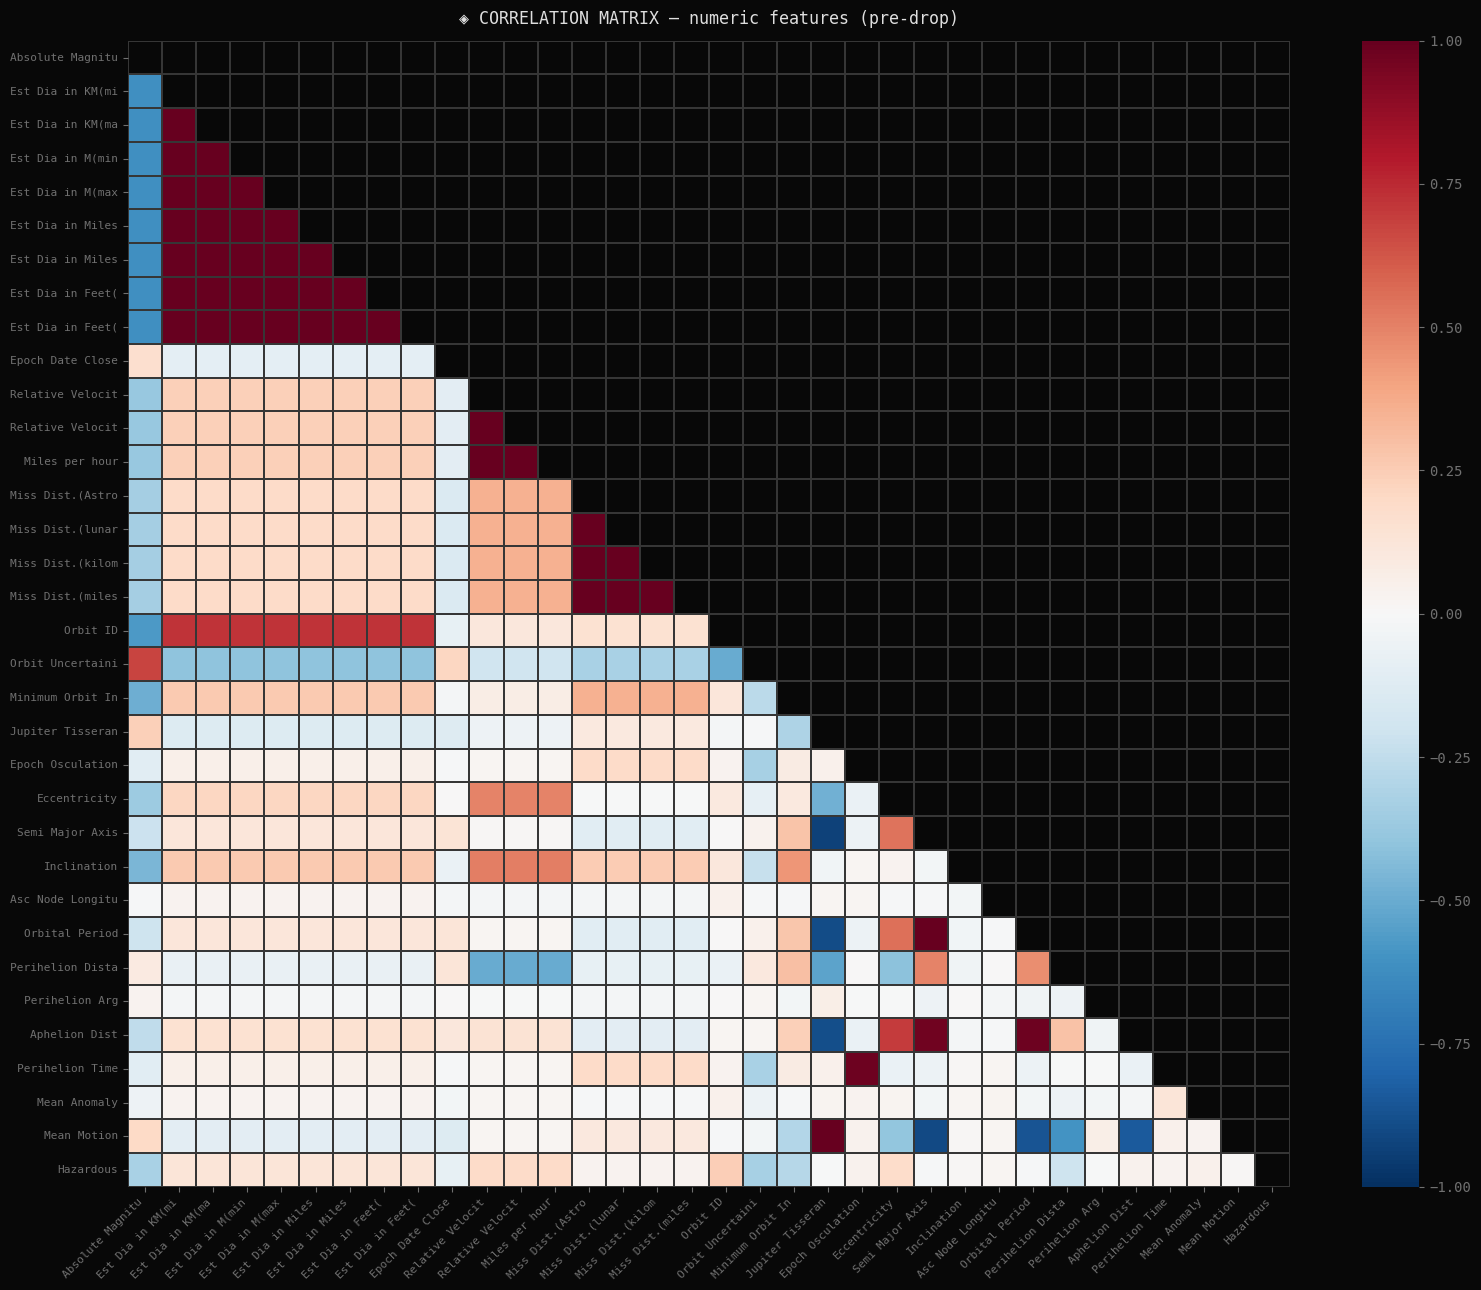

High-correlation pairs (|r| > 0.95, excluding self):
  Est Dia in KM(min)              ↔  Est Dia in KM(max)              r=1.000
  Est Dia in KM(min)              ↔  Est Dia in M(min)               r=1.000
  Est Dia in KM(min)              ↔  Est Dia in M(max)               r=1.000
  Est Dia in KM(min)              ↔  Est Dia in Miles(min)           r=1.000
  Est Dia in KM(min)              ↔  Est Dia in Miles(max)           r=1.000
  Est Dia in KM(min)              ↔  Est Dia in Feet(min)            r=1.000
  Est Dia in KM(min)              ↔  Est Dia in Feet(max)            r=1.000
  Est Dia in KM(max)              ↔  Est Dia in M(min)               r=1.000
  Est Dia in KM(max)              ↔  Est Dia in M(max)               r=1.000
  Est Dia in KM(max)              ↔  Est Dia in Miles(min)           r=1.000
  Est Dia in KM(max)              ↔  Est Dia in Miles(max)           r=1.000
  Est Dia in KM(max)              ↔  Est Dia in Feet(min)            r=1.000
  Est Dia in KM(max)   

In [7]:
df_num = df.drop(columns=ALWAYS_DROP).copy()
df_num['Hazardous'] = df_num['Hazardous'].astype(int)
corr = df_num.select_dtypes(include='number').corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, ax=ax, linewidths=0.3, linecolor=PALETTE['border'],
    xticklabels=[c[:16] for c in corr.columns],
    yticklabels=[c[:16] for c in corr.columns],
)
ax.set_title('◈ CORRELATION MATRIX — numeric features (pre-drop)', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('output/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("High-correlation pairs (|r| > 0.95, excluding self):")
printed = 0
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        c = corr.iloc[i, j]
        if abs(c) > 0.95:
            print(f"  {corr.columns[i]:<30}  ↔  {corr.columns[j]:<30}  r={c:.3f}")
            printed += 1
if printed == 0:
    print("  (none)")

## 5. Feature distributions — SAFE vs DANGEROUS

We visualise the five most discriminative features as overlapping histograms.
MOID should show the strongest separation: PHAs cluster near 0 AU by definition.

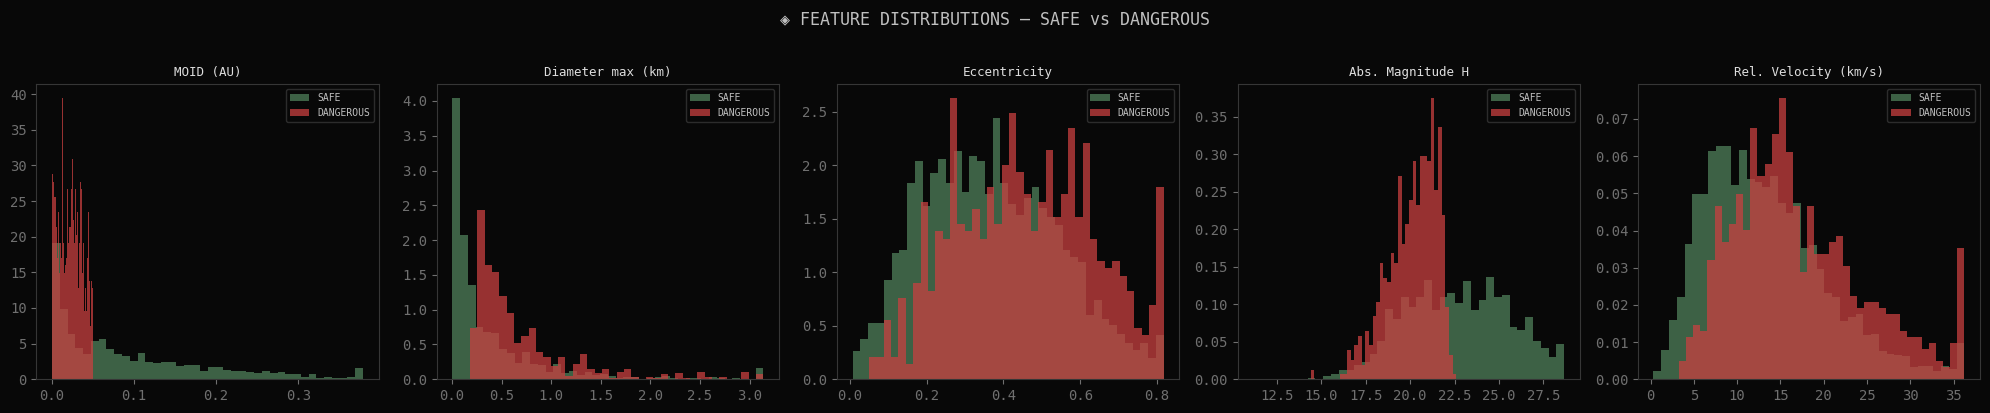

In [8]:
KEY_FEATURES = [
    ('Minimum Orbit Intersection', 'MOID (AU)'),
    ('Est Dia in KM(max)',          'Diameter max (km)'),
    ('Eccentricity',               'Eccentricity'),
    ('Absolute Magnitude',         'Abs. Magnitude H'),
    ('Relative Velocity km per sec','Rel. Velocity (km/s)'),
]

haz = df['Hazardous'] == True
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (col, label) in zip(axes, KEY_FEATURES):
    p99 = df[col].quantile(0.99)
    ax.hist(df.loc[~haz, col].clip(upper=p99).dropna(),
            bins=40, alpha=0.55, color=PALETTE['ok'],   label='SAFE',     density=True)
    ax.hist(df.loc[haz,  col].clip(upper=p99).dropna(),
            bins=40, alpha=0.75, color=PALETTE['crit'], label='DANGEROUS',density=True)
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor(PALETTE['border'])

fig.suptitle('◈ FEATURE DISTRIBUTIONS — SAFE vs DANGEROUS', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('output/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Pair plot — top discriminative features

The pair plot shows joint distributions of five key features, colour-coded by class.
Good class separation in a pairplot pair confirms the feature is useful for modelling.
Tight DANGEROUS clusters confirm that PHAs occupy a specific region of feature space.

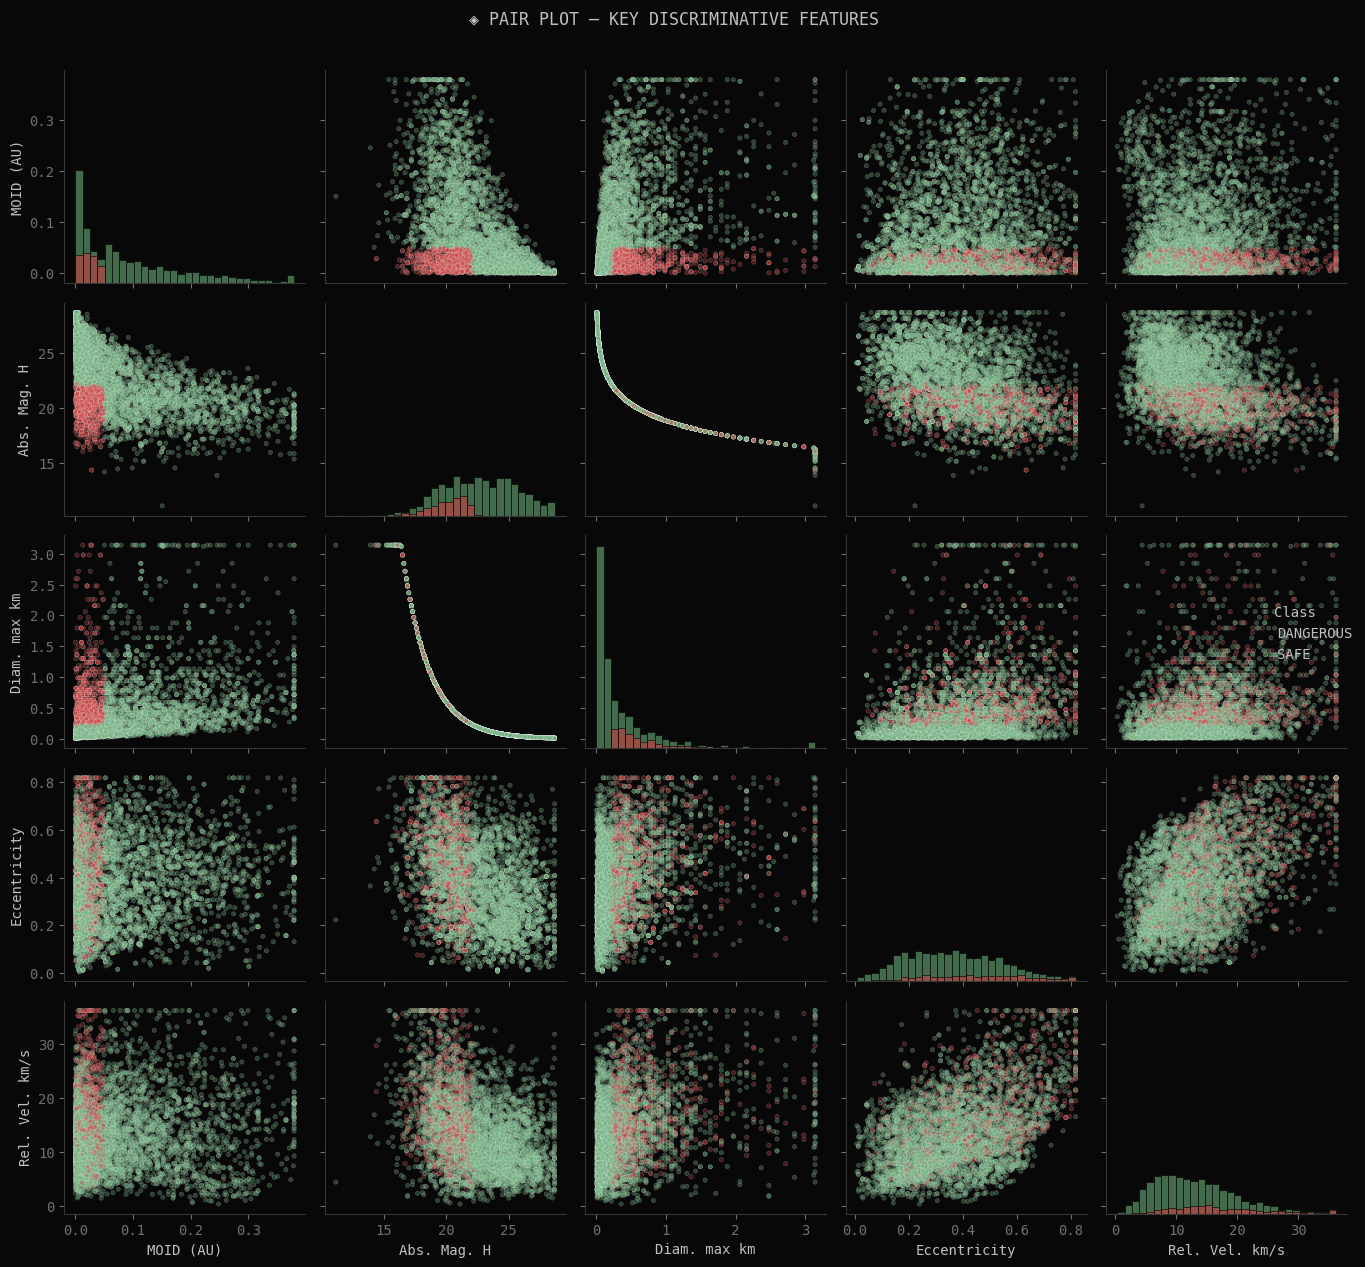

In [9]:
PAIR_COLS = [
    'Minimum Orbit Intersection', 'Absolute Magnitude',
    'Est Dia in KM(max)', 'Eccentricity', 'Relative Velocity km per sec',
]
SHORT = {
    'Minimum Orbit Intersection': 'MOID (AU)',
    'Absolute Magnitude':         'Abs. Mag. H',
    'Est Dia in KM(max)':         'Diam. max km',
    'Eccentricity':               'Eccentricity',
    'Relative Velocity km per sec':'Rel. Vel. km/s',
}

df_pair = df[PAIR_COLS + ['Hazardous']].copy()
df_pair['Class'] = df_pair['Hazardous'].map({True: 'DANGEROUS', False: 'SAFE'})
for col in PAIR_COLS:
    df_pair[col] = df_pair[col].clip(upper=df_pair[col].quantile(0.99))
df_pair = df_pair.rename(columns=SHORT).drop(columns=['Hazardous'])

g = sns.pairplot(
    df_pair, hue='Class',
    palette={'DANGEROUS': PALETTE['crit'], 'SAFE': PALETTE['ok']},
    plot_kws={'alpha': 0.35, 's': 10},
    diag_kind='hist', diag_kws={'alpha': 0.6, 'bins': 30},
)
g.figure.suptitle('◈ PAIR PLOT — KEY DISCRIMINATIVE FEATURES', y=1.01, fontsize=12)
for ax in g.axes.flat:
    ax.set_facecolor(PALETTE['bg'])
    for spine in ax.spines.values():
        spine.set_edgecolor(PALETTE['border'])
g.figure.set_facecolor(PALETTE['bg'])
plt.tight_layout()
plt.savefig('output/pair_plot.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. EDA Summary

**Dataset:** 4,687 NEO objects, 40 original columns.

**Class imbalance:** The majority class (non-hazardous) dominates. The exact ratio will be
printed by cell 2. This imbalance is the central modelling challenge — naive accuracy is
a misleading metric, and addressing this drives Phases 3 and 5.

**Features after cleaning:** 13 features retained (see cell 5 output).
The dropped columns are either unit-redundant (confirmed by correlation matrix),
derived quantities (Orbital Period from Kepler's 3rd law, q/Q from a and e),
administrative, or angular orientation elements with no direct bearing on hazard level.

**Key visual findings:**
- MOID (Minimum Orbit Intersection Distance) shows the strongest class separation:
  PHAs cluster below 0.05 AU, non-PHAs extend to > 0.5 AU. This will be the dominant
  feature — we verify this quantitatively in notebook 05 (MOID ablation).
- Diameter and absolute magnitude H are strongly anti-correlated (larger = brighter at
  same distance = lower H value). Both discriminate hazardous objects but are redundant
  with each other; we keep both as the RF handles collinearity well.
- Eccentricity and relative velocity show moderate separation.

**Preprocessing decisions carried to notebook 02:**
- Drop list: ALL_DROP (printed in cell 5)
- Keep list: FEATURES_KEPT (13 columns)
- Encoding: `Hazardous` bool → int (False→0, True→1)
- Splitting: stratified 80/20, random_state=42
- Scaling: StandardScaler fit on train only